In [69]:
#preserved concepts
import concept_getters
import pandas as pd
import re
SPARSITY_RATIOS_LTH = [0.0, 20.0, 36.0, 48.8, 59.04, 67.232, 73.786, 79.028, 83.223, 86.578, 89.263, 91.41, 93.128, 94.502]
SPARSITY_RATIOS_WANDA = [0.0, 19.987, 35.97, 48.796, 59.017, 67.22, 73.763, 79.004, 83.203, 86.556, 89.258, 91.406, 93.099, 94.499]

import collections

def get_indiv_concepts_per_unit(df) -> dict:
    concepts = {}
    for unit,expl in zip(df.unit, df.best_name):
        concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', expl)
        for i in range(len(concps)):
            while concps[i][-1] == ')':
                concps[i] = concps[i][:-1]
        concepts[unit] = concps
    return concepts

def get_concepts_across_pruning_per_neuron(method, filename, sparsity_list):
    explanations = {}
    for sparsity in sparsity_list:
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/BERT/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster3IOUS1024N.csv")
        explanations[sparsity] = get_indiv_concepts_per_unit(cluster3_expls) 
    reordered = collections.defaultdict(dict)
    for sparsity, neurons in explanations.items():
        for neuron, concepts in neurons.items():
            reordered[neuron][sparsity] = concepts
    return reordered 

def get_concepts_assoc_sparsities(method, filename, sparsity_list):
    explanations = {}
    for sparsity in sparsity_list:
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/BERT/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster3IOUS1024N.csv")
        explanations[sparsity] = get_indiv_concepts_per_unit(cluster3_expls) 
    reordered = collections.defaultdict(lambda: collections.defaultdict(set))
    for sparsity, neurons in explanations.items():
        for neuron, concepts in neurons.items():
            for concept in concepts:
                reordered[neuron][concept].add(sparsity)
    return reordered 

In [16]:
def count_frequencies(concepts_dict, neuron):
    concept_freq = []
    for list_of_concepts in concepts_dict[neuron].values():
        concept_freq.extend(list_of_concepts)
    concept_freq = collections.Counter(concept_freq)
    return {concept: freq for concept, freq in concept_freq.items() if freq > 5}
        
unique_concepts =set()
def num_unique_concepts_for_a_neuron(concepts_dict, neuron):
    concept_freq = []
    for list_of_concepts in concepts_dict[neuron].values():
        concept_freq.extend(list_of_concepts)
    concept_freq = collections.Counter(concept_freq)
    for concept in concept_freq:
        unique_concepts.add()
    return {concept: freq for concept, freq in concept_freq.items() if freq > 5}
                
        
        

In [9]:
list_of_repeated_concepts = set()

for neuron in reordered.keys():
    frequencies = count_frequencies(reordered,neuron)
    concepts = list(frequencies.keys())
    for c in concepts:
        list_of_repeated_concepts.add(c)


NameError: name 'reordered' is not defined

In [10]:
len(list_of_repeated_concepts) 
#across all neurons and all iterations, 160 concepts repeat within a neuron at least 5 times 
#(meaning across 1024 neurons there are 106 uniue concepts where across pruning they are dominant 5/14 iterations ) 
#doesnt show whether they're dominant in begining/middle/end just that they're preserved 30% of iters for at least 1 neuron

0

In [11]:
#graph for each neuron on avg how many concepts are repeated % of times
list_of_repeated_concepts = set()
unique = 0
for neuron in reordered.keys():
    frequencies = count_frequencies(reordered,neuron)
    num_u = num_unique_concepts_for_a_neuron(reordered,neuron)
    unique+=len(num_u)
    
    concepts = list(frequencies.keys())
num_u

NameError: name 'reordered' is not defined

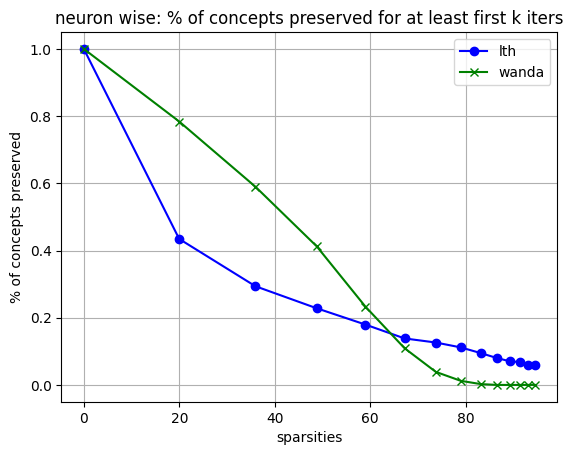

In [74]:
import matplotlib.pyplot as plt

def get_num_concpets_explained_originally(method, filename):
    unique_concepts=set()
    explanations = {}
    cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/BERT/exp/{method}/{filename}/Expls/{0.0}%Pruned/Cluster3IOUS1024N.csv")
    all_concept_at_original = get_indiv_concepts_per_unit(cluster3_expls) 
    for neuron, concepts in all_concept_at_original.items():
        for concept in concepts:
            unique_concepts.add(concept)
    return len(unique_concepts) 



def dropoff(method, filename, k, **kwargs):
    if method == 'wanda':
        sparsity_list = SPARSITY_RATIOS_WANDA
    elif method == 'lottery_ticket':
        sparsity_list = SPARSITY_RATIOS_LTH
        
    num_orig_cps = kwargs['num_orig_cps']
    concept_and_assoc_sparsities = kwargs['concept_assoc_sparsity']
    sparsity_mapping = kwargs['neuron_concept_sparsity_mapping']
    concepts_preserved=set()
    for neuron in sparsity_mapping.keys():
        for concept in concept_and_assoc_sparsities[neuron]:
            list_of_concepts_and_sprsty = list(concept_and_assoc_sparsities[neuron][concept])
            first_k_iters_present = sorted(list_of_concepts_and_sprsty)[:k]
            if first_k_iters_present == sparsity_list[:k]: #this concept is preserved for at lesat the first 6 iters
                concepts_preserved.add(concept)
    return len(concepts_preserved)/num_orig_cps


dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_LTH

for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(method, filename,sparsity_list)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(method, filename,sparsity_list)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    dropoffs_lth.append(percent_of_concepts_preserved)
    
dropoffs_wanda = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_WANDA
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(method, filename,sparsity_list)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(method, filename,sparsity_list)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    dropoffs_wanda.append(percent_of_concepts_preserved)
x=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)] 
plt.plot(x, dropoffs_lth, label='lth',color='blue', marker='o')
plt.plot(x, dropoffs_wanda, label='wanda',color='green', marker='x')
plt.title("neuron wise: % of concepts preserved for at least first k iters")
plt.xlabel("sparsities")
plt.ylabel("% of concepts preserved")
plt.legend()
plt.grid(True)

plt.show()

    

    
    
  

In [ ]:
neuron wise: % of neurons that preserve concepts for at lesat first k iters
    at each neuron set = true if there exists 1 concept that is preserved in the first k iters at least
    return num neurons=true/num neurons total  
    savee this val at index k in list 
    plot list

In [ ]:
def get_neurons_explained_originally(method, filename):
    unique_concepts=set()
    explanations = {}
    cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/BERT/exp/{method}/{filename}/Expls/{0.0}%Pruned/Cluster3IOUS1024N.csv")
    all_concept_at_original = get_indiv_concepts_per_unit(cluster3_expls) 
    return len(list(all_concept_at_original.keys()))

def dropoff(method, filename, k, **kwargs):
    if method == 'wanda':
        sparsity_list = SPARSITY_RATIOS_WANDA
    elif method == 'lottery_ticket':
        sparsity_list = SPARSITY_RATIOS_LTH
        
    num_orig_neurons = kwargs['num_orig_neurons']
    concept_and_assoc_sparsities = kwargs['concept_assoc_sparsity']
    sparsity_mapping = kwargs['neuron_concept_sparsity_mapping']
    neurons_preserved = [False for i in range(num_orig_neurons)]
    for i,neuron in enumerate(sparsity_mapping.keys()):
        for concept in concept_and_assoc_sparsities[neuron]:
            list_of_concepts_and_sprsty = list(concept_and_assoc_sparsities[neuron][concept])
            first_k_iters_present = sorted(list_of_concepts_and_sprsty)[:k]
            if first_k_iters_present == sparsity_list[:k]: #this concept is preserved for at lesat the first 6 iters
                neurons_preserved[i] = True
                break
    return torch.where(torch.tensor(neurons_preserved)==1, 1,0).sum()/num_orig_neurons


for k in range(1,15):
    neurons_orig_explained = get_neurons_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(method, filename,sparsity_list)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(method, filename,sparsity_list)
    percent_of_neurons_preserved = dropoff(method, filename, k, num_orig_neurons=neurons_orig_explained, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    dropoffs_lth.append(percent_of_neurons_preserved)
    
dropoffs_wanda = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_WANDA
for k in range(1,15):
    neurons_orig_explained = get_neurons_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(method, filename,sparsity_list)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(method, filename,sparsity_list)
    percent_of_neurons_preserved = dropoff(method, filename, k, num_orig_neurons=neurons_orig_explained, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    dropoffs_wanda.append(percent_of_neurons_preserved)

In [ ]:
globally: % of concepts that are preserved in kth pruning iter compared to original
    % of concepts preserved in kth pruning iter compared to the one prior to it 